## What is the most optimal skill to learn for DAta Analysts?

1. Continue from lastnotebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. Determine if certain technologies are more prevalent

In [4]:
#Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading the dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

In [6]:
df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US_exploded=df_DA_US.explode('job_skills')
df_DA_US_exploded[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [7]:
df_DA_skills=df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values('count',ascending=False)
df_DA_skills=df_DA_skills.rename(columns={'count':'skill_count','median':'median_salary'})
DA_job_count=len(df_DA_US)
df_DA_skills['skill_percent']=df_DA_skills['skill_count']/DA_job_count*100
skill_percents=5
df_DA_skills_high_demand=df_DA_skills[df_DA_skills['skill_percent']>=skill_percents]
df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


C:\Users\sandr\AppData\Local\Temp\ipykernel_25748\3689137226.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(plt.text(df_DA_skills_high_demand['skill_percent'][i], df_DA_skills_high_demand['median_salary'][i], txt))
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


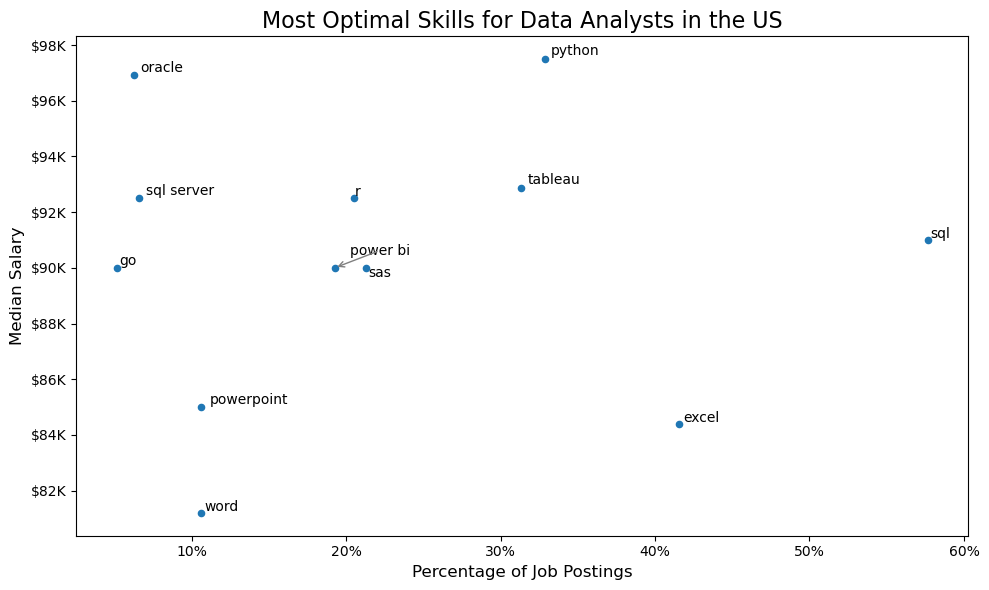

In [ ]:
from adjustText import adjust_text
fig, ax = plt.subplots()
df_DA_skills_high_demand.plot(kind='scatter',x='skill_percent',y='median_salary',ax=ax,figsize=(10,6))
texts = []
for i,txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'][i], df_DA_skills_high_demand['median_salary'][i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.title('Most Optimal Skills for Data Analysts in the US', fontsize=16)
plt.xlabel('Percentage of Job Postings', fontsize=12)
plt.ylabel('Median Salary', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
df_technology=df['job_type_skills']

In [10]:
#Remove NAN values
df_technology=df_technology.dropna()

#Combine all lists into one
technology_dict={}
for row in df_technology:
    row_dict=ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key]+=value
        else:
            technology_dict[key]=value

#remove duplicates by converting values to set them back to list
for key, value in technology_dict.items():
    technology_dict[key]=list(set(value))

technology_dict


{'analyst_tools': ['sas',
  'tableau',
  'spreadsheet',
  'splunk',
  'sharepoint',
  'excel',
  'dax',
  'qlik',
  'word',
  'esquisse',
  'cognos',
  'visio',
  'alteryx',
  'powerpoint',
  'sap',
  'looker',
  'microstrategy',
  'datarobot',
  'sheets',
  'msaccess',
  'ms access',
  'powerbi',
  'ssis',
  'outlook',
  'ssrs',
  'nuix',
  'power bi',
  'spss'],
 'programming': ['shell',
  'typescript',
  'java',
  'sas',
  'php',
  'sql',
  'javascript',
  'mongo',
  'solidity',
  'ruby',
  'html',
  'rust',
  'pascal',
  'haskell',
  'python',
  'vb.net',
  'c++',
  'objective-c',
  'vba',
  'powershell',
  'cobol',
  'r',
  'mongodb',
  'visual basic',
  'golang',
  'lisp',
  'perl',
  'julia',
  'go',
  'visualbasic',
  'lua',
  'matlab',
  'bash',
  'nosql',
  'scala',
  'ocaml',
  'f#',
  'elixir',
  'c',
  'groovy',
  'swift',
  'assembly',
  'css',
  'no-sql',
  'delphi',
  'dart',
  'crystal',
  'erlang',
  'fortran',
  'clojure',
  'kotlin',
  't-sql',
  'sass',
  'c#',
  '

In [12]:
import pandas as pd
df_technology=pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology=df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,sas
0,analyst_tools,tableau
0,analyst_tools,spreadsheet
0,analyst_tools,splunk
0,analyst_tools,sharepoint
...,...,...
9,sync,google chat
9,sync,wire
9,sync,symphony
9,sync,ringcentral


In [14]:
df_plot=df_DA_skills_high_demand.merge(df_technology,left_on='job_skills',right_on='skills')

C:\Users\sandr\AppData\Local\Temp\ipykernel_25748\925314794.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(plt.text(df_DA_skills_high_demand['skill_percent'][i], df_DA_skills_high_demand['median_salary'][i], txt))


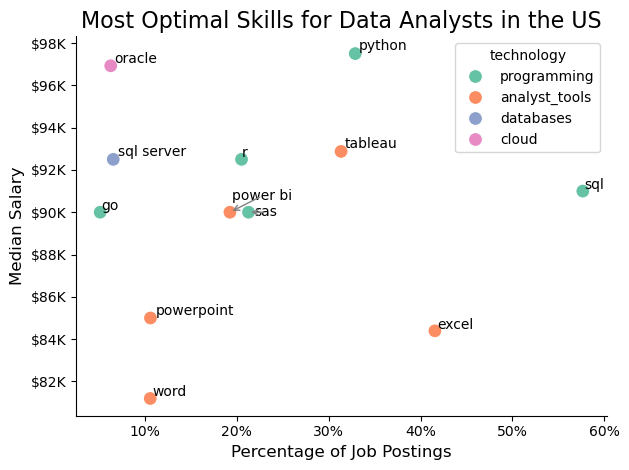

In [17]:
fig, ax = plt.subplots()
#df_plot.plot(kind='scatter',x='skill_percent',y='median_salary',ax=ax,figsize=(10,6))
sns.scatterplot(data=df_plot, x='skill_percent', y='median_salary', hue='technology', palette='Set2', s=100, ax=ax)
sns.despine()
texts = []
for i,txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'][i], df_DA_skills_high_demand['median_salary'][i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.title('Most Optimal Skills for Data Analysts in the US', fontsize=16)
plt.xlabel('Percentage of Job Postings', fontsize=12)
plt.ylabel('Median Salary', fontsize=12)
plt.tight_layout()
plt.show()